In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as so
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, accuracy_score, f1_score, classification_report,
                            confusion_matrix, roc_auc_score, RocCurveDisplay)
from google.colab import files


uploaded = files.upload()
D = pd.read_csv('diabetes_risk_dataset.csv')

# Cleaning up Variables Dataset (Converting Categorical data to Numerical data)
D['gender'] = D['gender'].map({'Female': 0, 'Male': 1})
D['physical_activity_level'] = D['physical_activity_level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
D['family_history_diabetes'] = D['family_history_diabetes'].map({'No' : 0, 'Yes' : 1})
D['diabetes_risk_category'] = D['diabetes_risk_category'].map({'Low Risk': 0, 'High Risk': 1, 'Prediabetes': 2})

Saving diabetes_risk_dataset.csv to diabetes_risk_dataset (2).csv


In [30]:
# Separating Explanatory and Response Variables
Y = D["diabetes_risk_category"]
X = D.drop(["diabetes_risk_score", "diabetes_risk_category", "Patient_ID"], axis=1)
# Making the train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=41)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, not fit_transform

In [31]:
D

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,0,33.8,154,93,12.1,5.2,242,194,0,2169,78.4,8.1,4,0,101.1,52.3,2
1,2,54,1,19.2,123,94,4.6,5.4,212,76,2,1881,16.5,6.6,3,0,60.0,3.7,0
2,3,25,1,33.7,141,150,10.8,6.9,247,221,0,2811,147.9,6.7,10,1,114.7,87.3,1
3,4,23,0,32.8,140,145,11.6,6.8,195,193,0,2826,98.3,4.4,9,1,96.6,76.1,1
4,5,70,1,33.7,165,90,18.3,5.6,217,170,1,2610,65.8,9.1,5,1,107.4,47.7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5996,58,1,21.8,158,89,6.3,5.3,198,132,2,1995,44.1,7.6,7,0,82.7,0.0,0
5996,5997,73,1,47.3,193,109,33.7,6.1,250,209,0,3401,61.4,5.3,10,1,150.0,100.0,1
5997,5998,35,1,31.0,139,90,15.1,5.3,190,164,1,3022,86.7,6.8,3,1,102.7,22.3,0
5998,5999,58,1,26.2,136,88,6.3,5.5,223,126,2,2311,28.2,8.4,5,0,90.6,3.9,0


In [32]:
# Logistic Regression (not scaled)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.3f}")
print(f"F1 (macro): {f1_score(y_test, lr_preds, average='macro'):.3f}")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy:  0.808
F1 (macro): 0.751
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       506
           1       0.84      0.89      0.86       447
           2       0.56      0.45      0.50       247

    accuracy                           0.81      1200
   macro avg       0.76      0.75      0.75      1200
weighted avg       0.80      0.81      0.80      1200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
# Logistic Regression (scaled)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.3f}")
print(f"F1 (macro): {f1_score(y_test, lr_preds, average='macro'):.3f}")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy:  0.948
F1 (macro): 0.936
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       506
           1       0.98      0.97      0.97       447
           2       0.87      0.88      0.87       247

    accuracy                           0.95      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.95      0.95      0.95      1200



In [34]:
print(lr.classes_)

[0 1 2]


=== Random Forest ===
Accuracy:  0.918
F1 (macro): 0.900
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       506
           1       0.96      0.94      0.95       447
           2       0.79      0.81      0.80       247

    accuracy                           0.92      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.92      0.92      0.92      1200



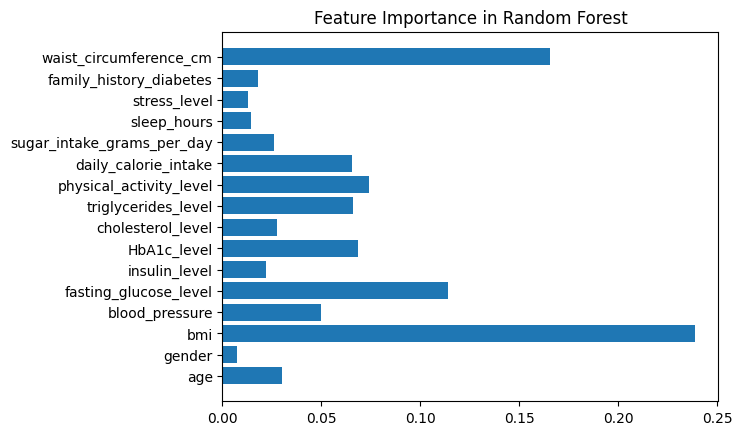

In [35]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=41)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 (macro): {f1_score(y_test, y_pred, average='macro'):.3f}")
print(classification_report(y_test, y_pred))

importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance in Random Forest")
plt.show()

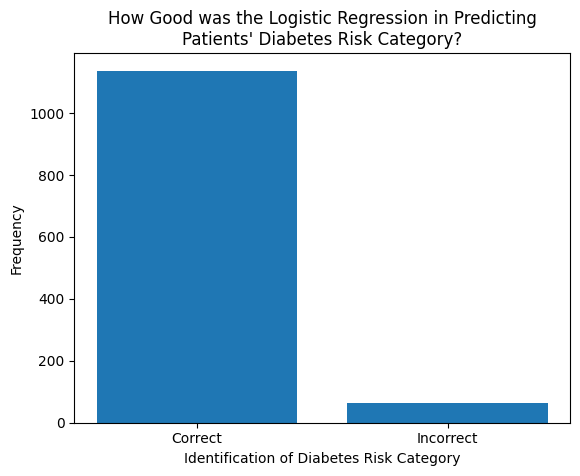

In [36]:
# Showing how good the models are!

# 1. The logistic regression model

columns = ['Correct', 'Incorrect']
frequencies = [0, 0]
for i in range(len(y_test)):
  if y_test.iloc[i] != lr_preds[i]:
    frequencies[1] += 1
  else:
    frequencies[0] += 1

plt.bar(columns, frequencies)
plt.title("How Good was the Logistic Regression in Predicting\nPatients' Diabetes Risk Category?")
plt.xlabel("Identification of Diabetes Risk Category")
plt.ylabel("Frequency")
plt.show()



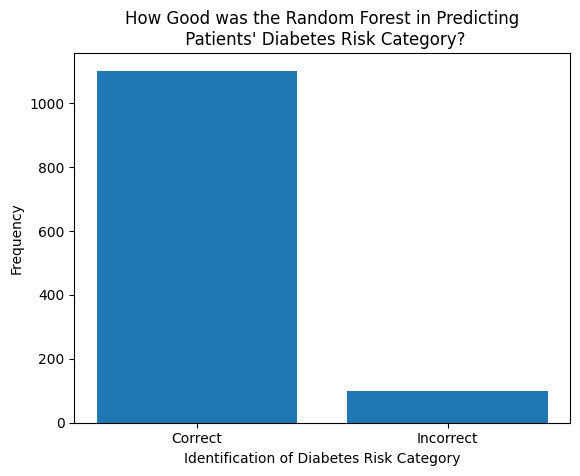

In [37]:
columns = ['Correct', 'Incorrect']
frequencies = [0, 0]
for i in range(len(y_test)):
  if y_test.iloc[i] != y_pred[i]:
    frequencies[1] += 1
  else:
    frequencies[0] += 1

plt.bar(columns, frequencies)
plt.title("How Good was the Random Forest in Predicting\n Patients' Diabetes Risk Category?")
plt.xlabel("Identification of Diabetes Risk Category")
plt.ylabel("Frequency")
plt.show()

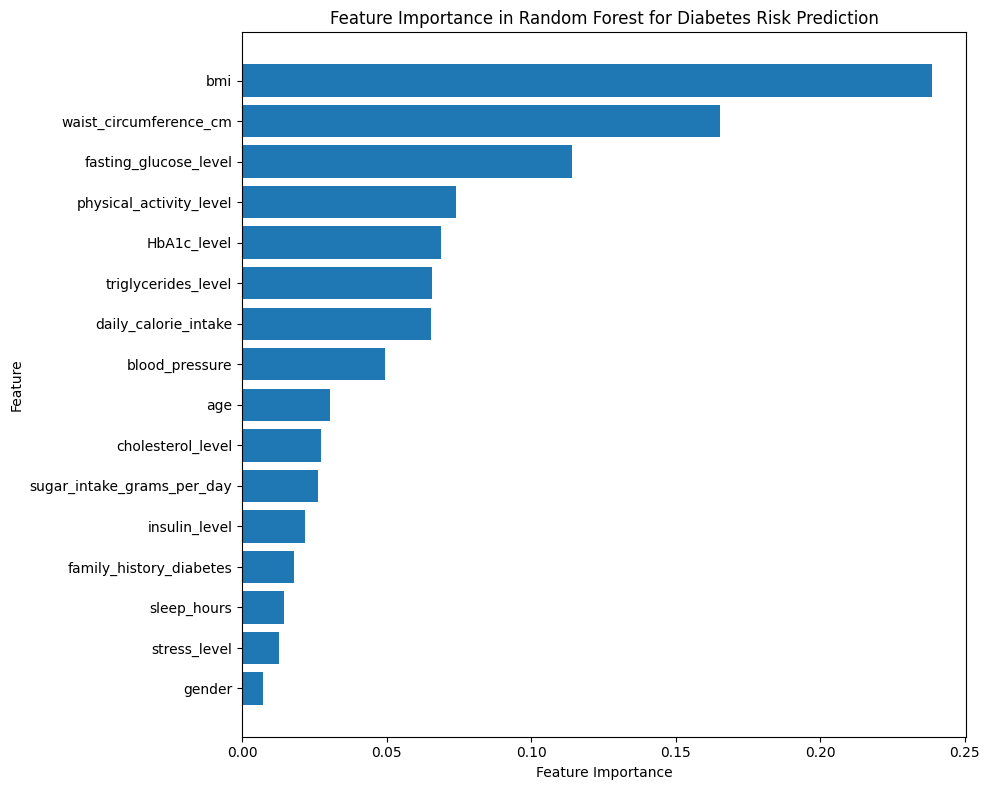

In [38]:
rf_importances = rf_model.feature_importances_
features = X.columns

# Sort features by importance for better visualization
sorted_idx = rf_importances.argsort()

plt.figure(figsize=(10, 8))
plt.barh(features[sorted_idx], importances[sorted_idx])
plt.title("Feature Importance in Random Forest for Diabetes Risk Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

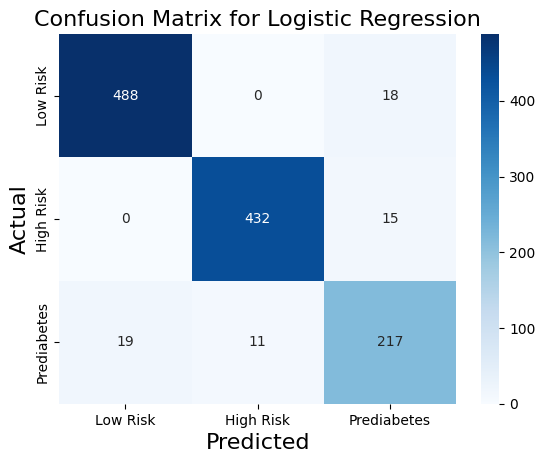

In [39]:
cf_matrix_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cf_matrix_lr, annot=True, cmap='Blues', fmt='g', xticklabels=['Low Risk', 'High Risk', 'Prediabetes'], yticklabels=['Low Risk', 'High Risk', 'Prediabetes'])
plt.xlabel('Predicted', fontsize=16)
plt.ylabel('Actual', fontsize=16)
plt.title('Confusion Matrix for Logistic Regression', fontsize=16)
plt.show()

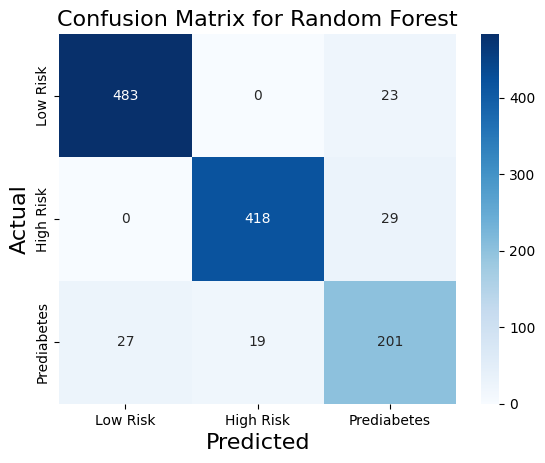

In [40]:
cf_matrix_rf = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix_rf, annot=True, cmap='Blues', fmt='g', xticklabels=['Low Risk', 'High Risk', 'Prediabetes'], yticklabels=['Low Risk', 'High Risk', 'Prediabetes'])
plt.xlabel('Predicted', fontsize=16)
plt.ylabel('Actual', fontsize=16)
plt.title('Confusion Matrix for Random Forest', fontsize=16)
plt.show()

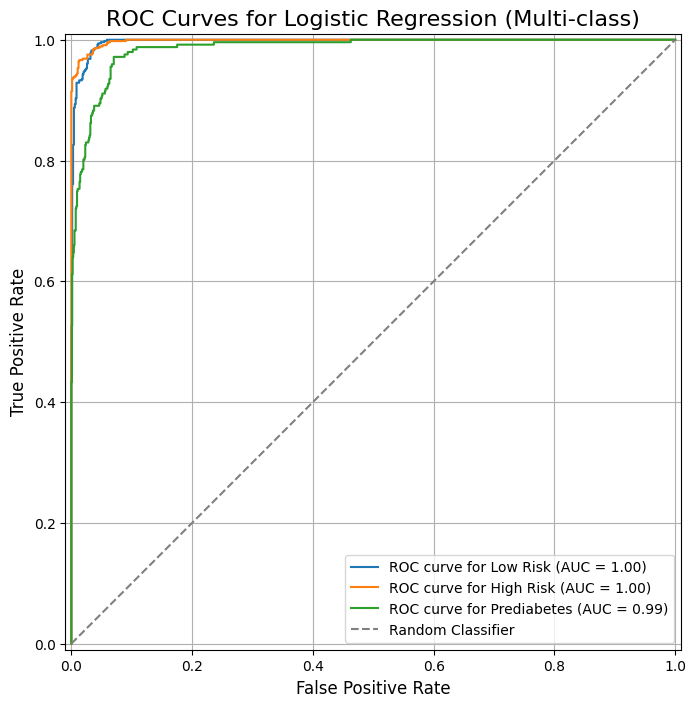

In [43]:
from sklearn.preprocessing import LabelBinarizer

# Get predicted probabilities for each class from the logistic regression model
lr_probs = lr.predict_proba(X_test_scaled)

# Binarize the true labels for multi-class ROC curve
label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)

n_classes = y_test_binarized.shape[1]

# Map numerical labels to risk categories for plotting
class_labels = {0: 'Low Risk', 1: 'High Risk', 2: 'Prediabetes'}

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        lr_probs[:, i],
        name=f"ROC curve for {class_labels[i]}",
        ax=plt.gca(),
        drop_intermediate=False,
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.title('ROC Curves for Logistic Regression (Multi-class)', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()

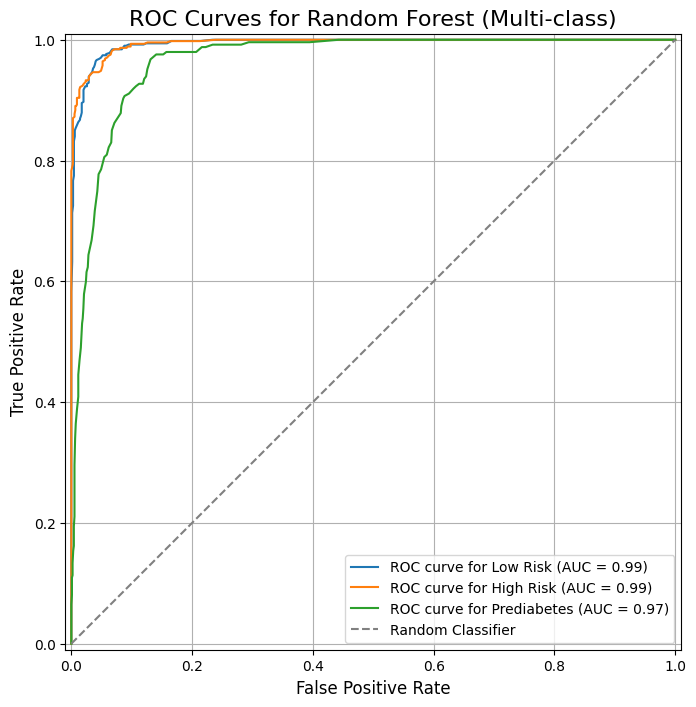

In [42]:
#ROC curve for Random Forest
from sklearn.preprocessing import LabelBinarizer

# Get predicted probabilities for each class from the random forest model
rf_probs = rf_model.predict_proba(X_test)

label_binarizer = LabelBinarizer().fit(y_train)
y_test_binarized = label_binarizer.transform(y_test)

n_classes = y_test_binarized.shape[1]

# Map numerical labels to risk categories for plotting
class_labels = {0: 'Low Risk', 1: 'High Risk', 2: 'Prediabetes'}

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],
        rf_probs[:, i],
        name=f"ROC curve for {class_labels[i]}",
        ax=plt.gca(),
        drop_intermediate=False,
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.title('ROC Curves for Random Forest (Multi-class)', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.show()
